In [85]:
## Cleaning
import pandas as pd
import re
import datetime
import ast
import math

# KMeans
from sklearn.cluster import KMeans

# Kmedoids
from sklearn_extra.cluster import KMedoids

# Global
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer


In [87]:
##Load File Gempa pada bulan November dan Desember tahun 2023 yang masih kotor

des = pd.read_csv('./datasets/gempa_bumi_desember_dirty.csv')

In [88]:
##Untuk menghapus data duplikat yang memiliki string UPDATE dan langsung akan dihapus


des = des.rename(columns={'created_at;id_str;full_text;quote_count;reply_count;retweet_count;favorite_count;lang;user_id_str;conversation_id_str;username;tweet_url': 'Unnamed: 0'})
index = des[des['Unnamed: 0'].str.contains('UPDATE')].index
des.drop(index, inplace=True)

des_nov

[                                            Unnamed: 0  \
 0    Sun Dec 31 23:18:11 +0000 2023;174159966158732...   
 1    Sun Dec 31 07:38:09 +0000 2023;174136309376948...   
 2    Sun Dec 31 05:48:08 +0000 2023;174133540656896...   
 4    Sun Dec 31 05:11:40 +0000 2023;174132623155831...   
 5    Sun Dec 31 04:55:37 +0000 2023;174132219405416...   
 ..                                                 ...   
 822  Fri Dec 01 04:22:09 +0000 2023;173044213503454...   
 823  Fri Dec 01 02:35:09 +0000 2023;173041520660885...   
 824  Fri Dec 01 01:46:10 +0000 2023;173040287832879...   
 825  Fri Dec 01 01:11:08 +0000 2023;173039406279104...   
 827  Fri Dec 01 00:36:41 +0000 2023;173038539199444...   
 
                    Unnamed: 1                 Unnamed: 2  \
 0     01-Jan-2024 06:11:23WIB                 Lok:1.89LS   
 1     31-Dec-2023 14:35:34WIB                 Lok:6.84LS   
 2     31-Dec-2023 12:43:38WIB                 Lok:6.74LS   
 4            Kedalaman: 10 km   31 Des 2023 1

In [89]:
clean

temp = des.drop(['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'], axis=1)
clean.append(temp.dropna())
    
clean

[                                            Unnamed: 0  \
 0    Sun Dec 31 23:18:11 +0000 2023;174159966158732...   
 1    Sun Dec 31 07:38:09 +0000 2023;174136309376948...   
 2    Sun Dec 31 05:48:08 +0000 2023;174133540656896...   
 5    Sun Dec 31 04:55:37 +0000 2023;174132219405416...   
 7    Sun Dec 31 04:55:14 +0000 2023;174132209519445...   
 ..                                                 ...   
 821  Fri Dec 01 04:58:08 +0000 2023;173045119065441...   
 822  Fri Dec 01 04:22:09 +0000 2023;173044213503454...   
 823  Fri Dec 01 02:35:09 +0000 2023;173041520660885...   
 824  Fri Dec 01 01:46:10 +0000 2023;173040287832879...   
 825  Fri Dec 01 01:11:08 +0000 2023;173039406279104...   
 
                    Unnamed: 1    Unnamed: 2  \
 0     01-Jan-2024 06:11:23WIB    Lok:1.89LS   
 1     31-Dec-2023 14:35:34WIB    Lok:6.84LS   
 2     31-Dec-2023 12:43:38WIB    Lok:6.74LS   
 5      31-Des-23 11:52:34 WIB   Lok:8.22 LS   
 7     31-Dec-2023 11:52:33WIB    Lok:8.25LS   
 .

In [90]:
def split_rad(text):
    rad = re.search(r"\((.*?)\)", text)

    if rad is not None:
        temp =  rad.group(1).split()
        return temp[0]
    return "delete"

def split_prov(text):
    prov = re.search(r"\((.*?)\)", text)

    if prov is not None: 
        newText = prov.group(1)
        split = newText.split()
        temp = split[-1].split('-')
        
        return temp[-1]
    return "delete"

def split_mag(text):
    mag = re.search(r"(\d+\.\d+)\s*(Mag(?:nitudo)?)?", text)

    return mag.group(1)

def split_depth(text):   
    depth = re.search(r":\s*(\d+)", str(text))

    return depth.group(1)

def split_lat(text):
    return text.replace("Lok:", "")

def split_lon(text):
    return text.split()[0]

def split_date(text):
    date = text.split()[1:3]

    return date[0]

In [93]:
nov_des = pd.DataFrame()

for i in range(len(clean)):
    date = clean[i][:]["Unnamed: 0"].apply(split_date)
    mag = clean[i][:]["Unnamed: 0"].apply(split_mag)
    depth = clean[i][:]["Unnamed: 4"].apply(split_depth)
    rad = clean[i][:]["Unnamed: 3"].apply(split_rad)
    prov = clean[i][:]["Unnamed: 3"].apply(split_prov)
    lat = clean[i][:]["Unnamed: 2"].apply(split_lat)
    lon = clean[i][:]["Unnamed: 3"].apply(split_lon)
 
    nov_des["mag"] = mag
    nov_des["depth"] = depth
    nov_des["rad"] = rad
    nov_des["lat"] = lat
    nov_des["lon"] = lon
    
    nov_des["prov"] = prov
    nov_des["date"] = date

nov_des

,mag,depth,rad,lat,lon,prov,date
0,2.9,10,85,1.89LS,122.53BT,SULTENG,Dec
1,4.1,10,2,6.84LS,107.93BT,JABAR,Dec
2,2.9,10,27,6.74LS,106.60BT,JABAR,Dec
5,5.0,10,90,8.22 LS,107.87,JABAR,Dec
7,5.0,10,93,8.25LS,107.86BT,JABAR,Dec
...,...,...,...,...,...,...,...
821,3.2,10,29,4.54LU,96.59BT,ACEHTENGAH,Dec
822,2.9,10,107,1.78LU,122.85BT,SULUT,Dec
823,4.4,386,187,6.47LS,127.97BT,MALUKUBRTDAYA,Dec
824,3.1,24,69,1.39LU,126.93BT,MALUT,Dec


In [94]:
def extract_quake_data(text):
    lon = None
    lat = None
    
    magnitude = re.search(r"Mag:(\d+\.\d+)", text).group(1)
    location = re.search(r"\((.+?)\)", text).group(1)
    depth = re.search(r"Kedlmn:(\d+)", text).group(1)
    prov = location.split()[-1].split('-')[-1]
    rad = location.split()[0]
    date = re.search(r"(\d{2}-\w{3}-\d{2,4})", text).group(1)
    
    pattern = r"Lok:(\d+\.\d+\w+)\s+(\d+\.\d+)\w+"
    match = re.search(pattern, text)
    
    if match:
        lat = match.group(1)
        
        lon_str = match.group(0)
        lon = lon_str.split(" ")[1]

    if date:
        newDate = date.split('-')
        date = newDate[1]

    quake_data = {
        "mag": magnitude,
        "depth": depth,
        "rad": rad,
        "lat": lat,
        "lon": lon,
        "prov": prov,
        "date": date,
    }

    return quake_data

In [95]:
month_dirty = [
    pd.read_csv('./datasets/gempa_bumi_januari.csv'),
    pd.read_csv('./datasets/gempa_bumi_februari.csv'), 
    pd.read_csv('./datasets/gempa_bumi_maret.csv'),
    pd.read_csv('./datasets/gempa_bumi_april.csv')
]

month_clean = [  
]

for i in range(len(month_dirty)):
    cleaned = month_dirty[i][:]["full_text"].apply(extract_quake_data)
    month_clean.append(cleaned)

data_janap = pd.concat(month_clean)
data_janap = pd.DataFrame(data_janap.tolist())
data_janap

,mag,depth,rad,lat,lon,prov,date
0,3.6,10,74,3.92LS,133.71BT,PAPUABRT,Jan
1,2.6,164,3,1.49LU,99.64BT,SUMUT,Jan
2,4.5,182,165,4.60LS,129.69BT,MALUKUTENGAH,Jan
3,3.2,10,116,8.50LS,107.82BT,JABAR,Jan
4,5.0,11,129,1.96LU,126.60BT,MALUT,Jan
...,...,...,...,...,...,...,...
1311,2.9,10,30,2.66LS,121.63BT,SULTENG,Apr
1312,3.7,10,137,5.80LS,112.60BT,JATIM,Apr
1313,3.0,10,26,3.53LS,120.32BT,SULSEL,Apr
1314,3.6,10,115,5.96LS,112.49BT,JATIM,Apr


In [96]:
data = pd.concat([data_janap, nov_des])
data = data.dropna()
data

,mag,depth,rad,lat,lon,prov,date
0,3.6,10,74,3.92LS,133.71BT,PAPUABRT,Jan
1,2.6,164,3,1.49LU,99.64BT,SUMUT,Jan
2,4.5,182,165,4.60LS,129.69BT,MALUKUTENGAH,Jan
3,3.2,10,116,8.50LS,107.82BT,JABAR,Jan
4,5.0,11,129,1.96LU,126.60BT,MALUT,Jan
...,...,...,...,...,...,...,...
821,3.2,10,29,4.54LU,96.59BT,ACEHTENGAH,Dec
822,2.9,10,107,1.78LU,122.85BT,SULUT,Dec
823,4.4,386,187,6.47LS,127.97BT,MALUKUBRTDAYA,Dec
824,3.1,24,69,1.39LU,126.93BT,MALUT,Dec


In [97]:
def makeLatitude(text):
    lat = float(text[:-2])
    pattern = r"(LS|LU)"
    match = re.search(pattern, text)

    if match:
        if match.group(1) == "LS":
            lat = -1 * float(text[:-2])
        
        return abs(lat) if lat >= 0 else -abs(lat)

def makeLongitude(text):
    lon = float(text[:-2])
    pattern = r"(BT|BB)"
    match = re.search(pattern, text)

    if match:
        if match.group(1) == "BB":
            lon = -1 * float(text[:-2])
        
        return abs(lon) if lon >= 0 else -abs(lon)

In [98]:
data['lat'] = data[:]['lat'].apply(makeLatitude)
data['lon'] = data[:]['lon'].apply(makeLongitude)

data

,mag,depth,rad,lat,lon,prov,date
0,3.6,10,74,-3.92,133.71,PAPUABRT,Jan
1,2.6,164,3,1.49,99.64,SUMUT,Jan
2,4.5,182,165,-4.60,129.69,MALUKUTENGAH,Jan
3,3.2,10,116,-8.50,107.82,JABAR,Jan
4,5.0,11,129,1.96,126.60,MALUT,Jan
...,...,...,...,...,...,...,...
821,3.2,10,29,4.54,96.59,ACEHTENGAH,Dec
822,2.9,10,107,1.78,122.85,SULUT,Dec
823,4.4,386,187,-6.47,127.97,MALUKUBRTDAYA,Dec
824,3.1,24,69,1.39,126.93,MALUT,Dec


In [99]:
data = data.dropna()
data

,mag,depth,rad,lat,lon,prov,date
0,3.6,10,74,-3.92,133.71,PAPUABRT,Jan
1,2.6,164,3,1.49,99.64,SUMUT,Jan
2,4.5,182,165,-4.60,129.69,MALUKUTENGAH,Jan
3,3.2,10,116,-8.50,107.82,JABAR,Jan
4,5.0,11,129,1.96,126.60,MALUT,Jan
...,...,...,...,...,...,...,...
821,3.2,10,29,4.54,96.59,ACEHTENGAH,Dec
822,2.9,10,107,1.78,122.85,SULUT,Dec
823,4.4,386,187,-6.47,127.97,MALUKUBRTDAYA,Dec
824,3.1,24,69,1.39,126.93,MALUT,Dec


In [100]:
def encoded_loc(row, encode):
    if row['prov'] in encode:
        return encode[row['prov']]

    return None

unique_locs = data['prov'].unique()
mapLoc = {prov: i + 1 for i, prov in enumerate(unique_locs)}

data['prov_enco'] = data['prov'].map(mapLoc)
data

/tmp/ipykernel_11274/3138881448.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['prov_enco'] = data['prov'].map(mapLoc)


,mag,depth,rad,lat,lon,prov,date,prov_enco
0,3.6,10,74,-3.92,133.71,PAPUABRT,Jan,1
1,2.6,164,3,1.49,99.64,SUMUT,Jan,2
2,4.5,182,165,-4.60,129.69,MALUKUTENGAH,Jan,3
3,3.2,10,116,-8.50,107.82,JABAR,Jan,4
4,5.0,11,129,1.96,126.60,MALUT,Jan,5
...,...,...,...,...,...,...,...,...
821,3.2,10,29,4.54,96.59,ACEHTENGAH,Dec,9
822,2.9,10,107,1.78,122.85,SULUT,Dec,15
823,4.4,386,187,-6.47,127.97,MALUKUBRTDAYA,Dec,14
824,3.1,24,69,1.39,126.93,MALUT,Dec,5


In [101]:
x = data[['mag', 'depth', 'rad', 'prov_enco', 'lat', 'lon']]
x

,mag,depth,rad,prov_enco,lat,lon
0,3.6,10,74,1,-3.92,133.71
1,2.6,164,3,2,1.49,99.64
2,4.5,182,165,3,-4.60,129.69
3,3.2,10,116,4,-8.50,107.82
4,5.0,11,129,5,1.96,126.60
...,...,...,...,...,...,...
821,3.2,10,29,9,4.54,96.59
822,2.9,10,107,15,1.78,122.85
823,4.4,386,187,14,-6.47,127.97
824,3.1,24,69,5,1.39,126.93


In [102]:
scaler = Normalizer()
dataScaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

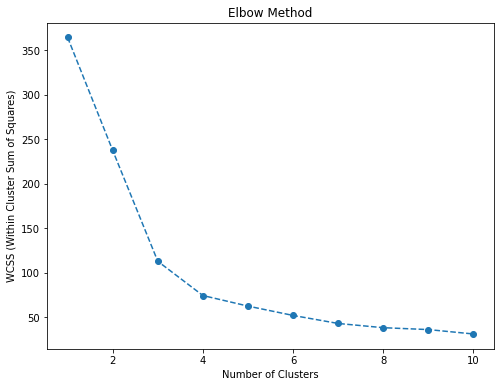

In [103]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(dataScaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [104]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

4

In [105]:
kmeans = KMeans(n_clusters=cluster_knee.elbow, random_state=42)
predict_kmeans = kmeans.fit(dataScaled)
kmeans.cluster_centers_

array([[ 0.02336856,  0.1182976 ,  0.61007037,  0.0815039 , -0.01959355,
         0.75885694],
       [ 0.01710285,  0.72043824,  0.26381528,  0.05986954, -0.01744121,
         0.57787732],
       [ 0.02532523,  0.13430847,  0.23763445,  0.09876001, -0.0282763 ,
         0.94087808],
       [ 0.01264186,  0.11292006,  0.91554122,  0.04305504,  0.00260389,
         0.32854085]])

In [106]:
data['kmeans'] = predict_kmeans.labels_
data['kmeans'].value_counts()

/tmp/ipykernel_11274/376390094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['kmeans'] = predict_kmeans.labels_


kmeans
2    707
0    657
1    340
3    235
Name: count, dtype: int64

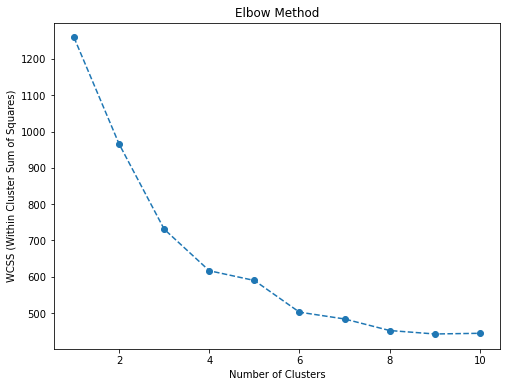

In [107]:
wcss = []

for i in range(1, 11):
    kMedoids = KMedoids(metric="manhattan", n_clusters=i, method='alternate', random_state=42)
    kMedoids.fit(dataScaled)
    wcss.append(kMedoids.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [108]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

4

In [109]:
kMedoids = KMedoids(n_clusters=cluster_knee.elbow, method='alternate', random_state=42)
predict_kmedoids = kMedoids.fit(dataScaled)
predict_kmedoids

KMedoids(n_clusters=4, random_state=42)

In [110]:
data['kmedoids'] = predict_kmedoids.labels_
data['kmedoids'].value_counts()

/tmp/ipykernel_11274/3650528949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['kmedoids'] = predict_kmedoids.labels_


kmedoids
2    682
0    665
1    356
3    236
Name: count, dtype: int64

In [111]:
data

,mag,depth,rad,lat,lon,prov,date,prov_enco,kmeans,kmedoids
0,3.6,10,74,-3.92,133.71,PAPUABRT,Jan,1,0,2
1,2.6,164,3,1.49,99.64,SUMUT,Jan,2,1,1
2,4.5,182,165,-4.60,129.69,MALUKUTENGAH,Jan,3,1,1
3,3.2,10,116,-8.50,107.82,JABAR,Jan,4,0,2
4,5.0,11,129,1.96,126.60,MALUT,Jan,5,0,2
...,...,...,...,...,...,...,...,...,...,...
821,3.2,10,29,4.54,96.59,ACEHTENGAH,Dec,9,2,0
822,2.9,10,107,1.78,122.85,SULUT,Dec,15,0,2
823,4.4,386,187,-6.47,127.97,MALUKUBRTDAYA,Dec,14,1,1
824,3.1,24,69,1.39,126.93,MALUT,Dec,5,0,2


In [112]:
data = data.drop(['mag', 'depth', 'rad', 'lat', 'lon', 'prov_enco'], axis=1)
data

,prov,date,kmeans,kmedoids
0,PAPUABRT,Jan,0,2
1,SUMUT,Jan,1,1
2,MALUKUTENGAH,Jan,1,1
3,JABAR,Jan,0,2
4,MALUT,Jan,0,2
...,...,...,...,...
821,ACEHTENGAH,Dec,2,0
822,SULUT,Dec,0,2
823,MALUKUBRTDAYA,Dec,1,1
824,MALUT,Dec,0,2


In [113]:
data.to_json('dataset-chart.json', orient='records', lines=False)